# Definición técnica + repositorio
En este notebook se realiza la preparación final de los datos para la fase de modelado, incluyendo la selección de variables relevantes y la transformación de variables categóricas mediante técnicas de codificación. Además, se define el enfoque técnico del proyecto, incluyendo los modelos de Machine Learning a utilizar, las métricas de evaluación y el uso de técnicas de interpretabilidad. Finalmente, se organiza la estructura del proyecto y el repositorio para su correcta gestión.


# Avance Semana 3

In [63]:
# Librerías
import pandas as pd

In [64]:
# Cargar dataset
df = pd.read_csv("../data/studentInfo.csv")

# Ver primeras filas
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [65]:
# Dimensiones del dataset
df.shape

(32593, 12)

In [66]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [67]:
# Columnas
df.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result'],
      dtype='object')

In [68]:
# Crear variable objetivo binaria
df['target'] = df['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0
})

In [69]:
# Ver distribución de la variable objetivo
df['target'].value_counts()

target
0    17208
1    15385
Name: count, dtype: int64

In [70]:
# Verificar valores nulos
df.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
target                     0
dtype: int64

In [71]:
# Estadísticas descriptivas
df.describe(include='all')

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593,32593.000000
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4,NaN
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass,NaN
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361,NaN
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN,0.472034
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN,0.499225
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN,0.000000
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,0.000000
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,0.000000
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN,1.000000


# Avance Semana 4

In [72]:
# Librerías
import matplotlib.pyplot as plt

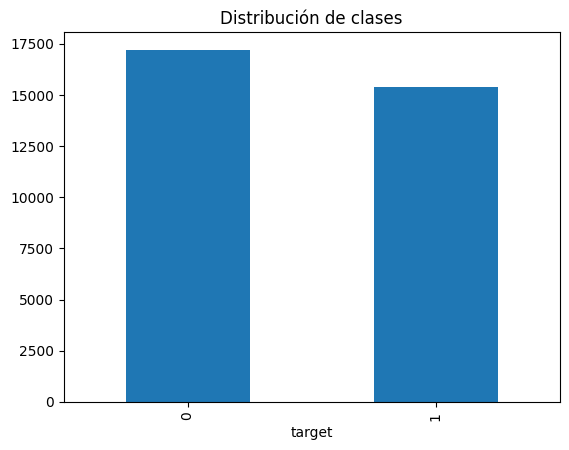

In [73]:
# Visualizar distribución de la variable objetivo
df['target'].value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.show()

In [74]:
# Analizar relación entre género y variable objetivo
pd.crosstab(df['gender'], df['target'])

target,0,1
gender,,
F,7589,7129
M,9619,8256


In [75]:
# Analizar relación entre educación y variable objetivo
pd.crosstab(df['highest_education'], df['target'])

target,0,1
highest_education,,
A Level or Equivalent,6737,7308
HE Qualification,2073,2657
Lower Than A Level,8046,5112
No Formal quals,244,103
Post Graduate Qualification,108,205


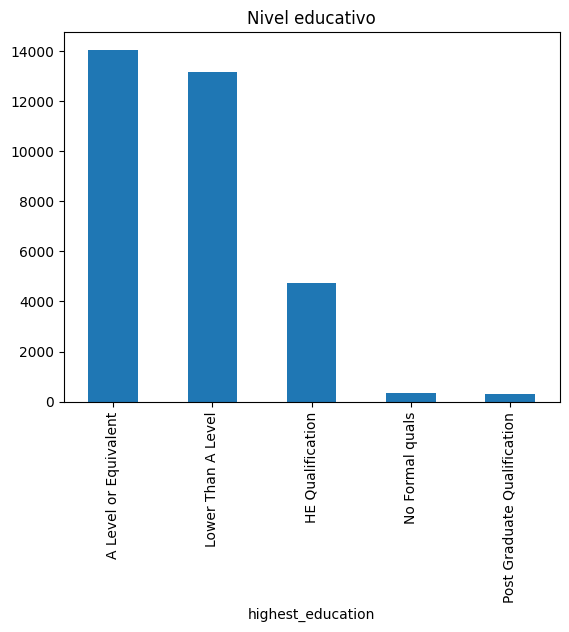

In [76]:
# Visualizar distribución de nivel educativo
df['highest_education'].value_counts().plot(kind='bar')
plt.title("Nivel educativo")
plt.show()

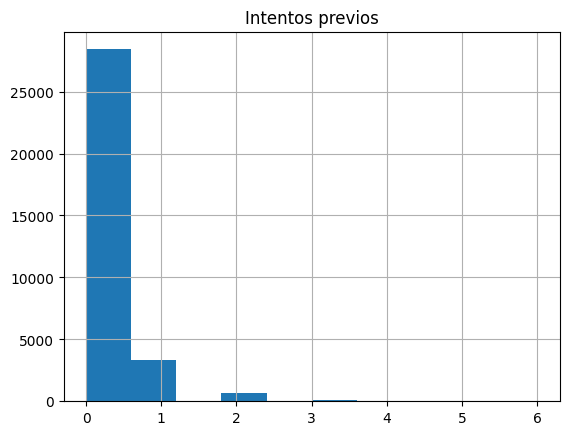

In [77]:
# Visualizar distribución de intentos previos
df['num_of_prev_attempts'].hist()
plt.title("Intentos previos")
plt.show()

In [78]:
# Ver proporción de clases
df['target'].value_counts(normalize=True)

target
0    0.527966
1    0.472034
Name: proportion, dtype: float64

# Avance Semana 5
Se realizo informe final

In [79]:
# Ejemplo eliminar columnas irrelevantes
df = df.drop(['id_student'], axis=1)

In [80]:
# Codificar variables categóricas
df_encoded = pd.get_dummies(df, drop_first=True)

In [81]:
# Ver dimensiones del dataset codificado
df_encoded.shape

(32593, 44)

In [82]:
# Guardar dataset preparado
df_encoded.to_csv("../data-preparada/dataset_preparado.csv", index=False)